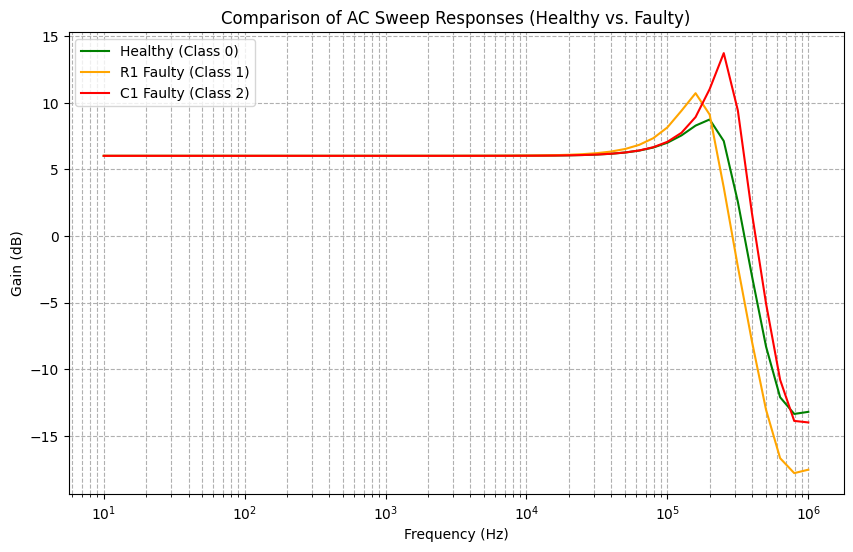

Dataset Successfully Created! Total Rows: 153


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dosyaları Okuma
columns = ["Frequency", "Gain_dB"]

df_healthy = pd.read_csv("healthy_baseline.csv", skiprows=1, names=columns)
df_r1_faulty = pd.read_csv("r1_faulty.csv", skiprows=1, names=columns)
df_c1_faulty = pd.read_csv("c1_faulty.csv", skiprows=1, names=columns)

# 2. Etiketleri Ekleme (Sınıflandırma için 0, 1, 2 değerleri)
df_healthy['Label'] = 0      # 0: Healthy (Sağlıklı)
df_r1_faulty['Label'] = 1    # 1: R1 Faulty (R1 Arızalı)
df_c1_faulty['Label'] = 2    # 2: C1 Faulty (C1 Arızalı)

# 3. Verileri Tek Bir Veri Setinde Birleştirme
dataset = pd.concat([df_healthy, df_r1_faulty, df_c1_faulty], ignore_index=True)

# 4. Veriyi Görselleştirme
plt.figure(figsize=(10,6))
plt.plot(df_healthy['Frequency'], df_healthy['Gain_dB'], label='Healthy (Class 0)', color='green')
plt.plot(df_r1_faulty['Frequency'], df_r1_faulty['Gain_dB'], label='R1 Faulty (Class 1)', color='orange')
plt.plot(df_c1_faulty['Frequency'], df_c1_faulty['Gain_dB'], label='C1 Faulty (Class 2)', color='red')

plt.xscale('log')
plt.title('Comparison of AC Sweep Responses (Healthy vs. Faulty)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print("Dataset Successfully Created! Total Rows:", len(dataset))

In [4]:
import pandas as pd
import numpy as np

# 1. Reading Proteus Files
columns = ["Frequency", "Gain_dB"]
df_healthy = pd.read_csv("healthy_baseline.csv", skiprows=1, names=columns)
df_r1_faulty = pd.read_csv("r1_faulty.csv", skiprows=1, names=columns)
df_c1_faulty = pd.read_csv("c1_faulty.csv", skiprows=1, names=columns)

# Extracting frequency values to use as column names (Features)
freq_columns = [f"Freq_{freq:.1f}Hz" for freq in df_healthy["Frequency"]]

# 2. Data Augmentation Function using Monte Carlo Method
# Takes a single baseline curve from Proteus and adds natural manufacturing tolerance (noise)
def augment_proteus_data(base_gain, label, num_samples=1000, noise_std=0.15):
    augmented_data = []
    for _ in range(num_samples):
        # Adding a realistic measurement noise (Gaussian) to each frequency point
        noisy_gain = base_gain + np.random.normal(0, noise_std, len(base_gain))
        augmented_data.append(list(noisy_gain) + [label])
    return augmented_data

# 3. Generating 1000 New Simulated Samples for Each Class
data_0 = augment_proteus_data(df_healthy["Gain_dB"].values, label=0)
data_1 = augment_proteus_data(df_r1_faulty["Gain_dB"].values, label=1)
data_2 = augment_proteus_data(df_c1_faulty["Gain_dB"].values, label=2)

# 4. Merging Data and Converting to a Pandas DataFrame
all_data = data_0 + data_1 + data_2
final_columns = freq_columns + ["Label"]

dataset_final = pd.DataFrame(all_data, columns=final_columns)

# Saving the final dataset as a CSV file
dataset_final.to_csv("proteus_augmented_dataset.csv", index=False)

print("Perfect matrix-format dataset successfully generated using Proteus data!")
print("Dataset Shape (Rows, Columns):", dataset_final.shape)
print("\nFirst 5 Rows of the Dataset:")
print(dataset_final.head())

Perfect matrix-format dataset successfully generated using Proteus data!
Dataset Shape (Rows, Columns): (3000, 52)

First 5 Rows of the Dataset:
   Freq_10.0Hz  Freq_12.6Hz  Freq_15.8Hz  Freq_20.0Hz  Freq_25.1Hz  \
0     6.098267     5.977937     5.870626     6.225750     5.920403   
1     5.965548     6.143819     6.134777     6.009929     6.264115   
2     5.875977     5.986160     6.208044     6.130203     6.342565   
3     5.977506     6.048184     6.159331     6.072676     5.597120   
4     6.015066     6.214458     6.168875     6.244681     5.843302   

   Freq_31.6Hz  Freq_39.8Hz  Freq_50.1Hz  Freq_63.1Hz  Freq_79.4Hz  ...  \
0     6.097864     6.121533     5.768486     6.030557     5.976006  ...   
1     6.096603     5.987498     5.934417     6.128699     5.848304  ...   
2     6.064126     5.752094     6.057256     6.149403     6.064705  ...   
3     5.906583     6.124231     6.215823     6.137665     5.701625  ...   
4     6.200349     6.011220     6.212884     6.057140     5

Model Accuracy: 100.00%


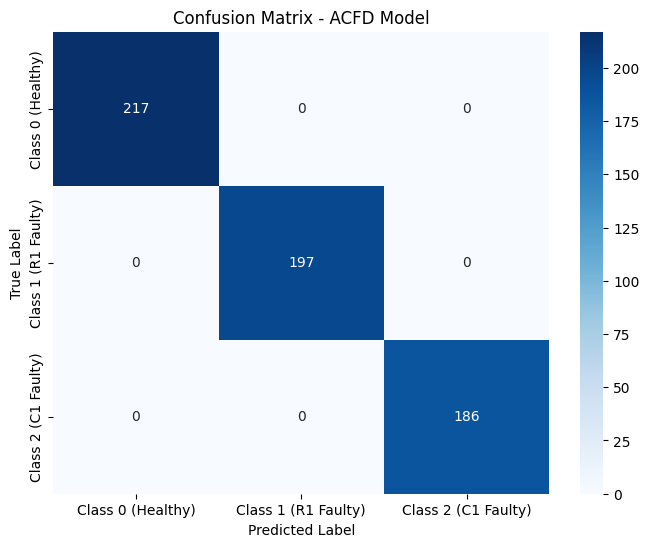

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load the dataset
dataset = pd.read_csv("proteus_augmented_dataset.csv")

# 2. Separate features (X) and labels (y)
X = dataset.drop("Label", axis=1)
y = dataset["Label"]

# 3. Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions on the test set
predictions = model.predict(X_test)

# 6. Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 7. Plot the Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Class 0 (Healthy)', 'Class 1 (R1 Faulty)', 'Class 2 (C1 Faulty)'],
            yticklabels=['Class 0 (Healthy)', 'Class 1 (R1 Faulty)', 'Class 2 (C1 Faulty)'])
plt.title("Confusion Matrix - ACFD Model")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()